# 4.2. Как провисает нить между опорами

Однородная гибкая нерастяжимая нить закреплена в двух точках. Расстояние между опорами по горизонтали принято за единицу длины, координата $y$ направлена вверх. Вес единицы длины нити обозначим $q$, горизонтальную составляющую натяжения — $H$. Требуется найти равновесную форму нити: сначала при заданном $a=H/q=1$, затем при заданной длине $L=1.2$ и разных высотах опор.

На нить не действуют распределённые горизонтальные силы, поэтому $H$ постоянно. Натяжение направлено по касательной; его вертикальная составляющая равна $Hy'$. Для элемента дуги $d\ell=\sqrt{1+(y')^2}\,dx$ равновесие по вертикали даёт
$$d(Hy')=q\,d\ell.$$
Следовательно,
$$y''=\frac1a\sqrt{1+(y')^2},\qquad a=\frac Hq>0.$$
Правая часть положительна: наклон возрастает вдоль нити, а профиль лежит ниже отрезка между опорами. Полное натяжение $\mathcal T(x)=H\sqrt{1+(y')^2}$ меняется с положением; постоянна только его горизонтальная составляющая.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11,
    "axes.grid": True, "grid.alpha": 0.22,
    "axes.spines.top": False, "axes.spines.right": False,
})
BLUE, ORANGE, GREEN, PURPLE = "#0072B2", "#D55E00", "#009E73", "#8B4BA5"

def table(headers, rows):
    # Формулы с модулем записываем через \lvert, чтобы не разбить столбцы.
    lines = ["| " + " | ".join(headers) + " |",
             "| " + " | ".join(["---"] * len(headers)) + " |"]
    lines += ["| " + " | ".join(map(str, row)) + " |" for row in rows]
    display(Markdown("\n".join(lines)))

def supports(ax, height):
    ax.scatter([0, 1], [0, height], s=48, color="black", zorder=8)
    ax.set(xlabel="$x$", ylabel="$y$", xlim=(-0.05, 1.05))
    ax.set_aspect("equal", adjustable="box")

def nonzero(values):
    values = np.asarray(values)
    return np.where(values > 0, values, np.nan)

## 1. Интегрирование профиля

Введём наклон $p=y'$ и длину дуги $\ell$, отсчитываемую от левой опоры. При заданных начальном наклоне $s$ и параметре $a$ получаем задачу Коши:
$$
\begin{pmatrix}y\\p\\\ell\end{pmatrix}'=
\begin{pmatrix}p\\\sqrt{1+p^2}/a\\\sqrt{1+p^2}\end{pmatrix},
\qquad (y,p,\ell)(0)=(0,s,0).
$$
Интегрируем на $[0,1]$ методом Рунге — Кутты четвёртого порядка (RK4). Для состояния $U=(y,p,\ell)$ с правой частью $f(U;a)$ один шаг имеет вид
$$
\begin{aligned}
k_1&=f(U_n;a), & k_2&=f(U_n+hk_1/2;a),\\
k_3&=f(U_n+hk_2/2;a), & k_4&=f(U_n+hk_3;a),\\
U_{n+1}&=U_n+\frac h6(k_1+2k_2+2k_3+k_4).
\end{aligned}
$$
Используем $N$ одинаковых шагов, $h=1/N$. Длина вычисляется вместе с профилем по той же схеме; отдельная квадратура по нарисованной ломаной не нужна.

In [2]:
def rhs(state, a):
    p = state[1]
    arc_factor = np.hypot(1.0, p)
    return np.array([p, arc_factor/a, arc_factor])

def integrate(s, a, n_steps):
    """Узлы x и значения (y, p, ell) для одного пробного профиля."""
    if not np.isfinite(s) or not np.isfinite(a) or a <= 0:
        raise ValueError("Нужны конечный наклон и конечное a > 0")
    if not isinstance(n_steps, (int, np.integer)) or n_steps <= 0:
        raise ValueError("N должно быть положительным целым числом")
    x = np.linspace(0, 1, n_steps + 1)
    h = 1/n_steps
    states = np.empty((n_steps + 1, 3))
    states[0] = [0, s, 0]
    with np.errstate(over="raise", invalid="raise", divide="raise"):
        for j in range(n_steps):
            u = states[j]
            k1 = rhs(u, a)
            k2 = rhs(u + h*k1/2, a)
            k3 = rhs(u + h*k2/2, a)
            k4 = rhs(u + h*k3, a)
            states[j+1] = u + h*(k1 + 2*k2 + 2*k3 + k4)/6
    if not np.all(np.isfinite(states)):
        raise FloatingPointError("Интегрирование дало неконечный профиль")
    return x, states

def bisect_root(fun, left, right, ftol=2e-14, xtol=2e-15, max_iter=100):
    """Бисекция: отдельно задаются допуски невязки и аргумента."""
    if not left < right or ftol <= 0 or xtol <= 0:
        raise ValueError("Нужны left < right и положительные допуски")
    fl, fr = fun(left), fun(right)
    if not np.isfinite(fl) or not np.isfinite(fr):
        raise ValueError("Невязки на концах должны быть конечными")
    if abs(fl) <= ftol:
        return left
    if abs(fr) <= ftol:
        return right
    if np.signbit(fl) == np.signbit(fr):
        raise ValueError("Интервал не содержит перемены знака")
    for _ in range(max_iter):
        middle = (left + right)/2
        fm = fun(middle)
        if not np.isfinite(fm):
            raise FloatingPointError("Неконечная невязка в бисекции")
        if abs(fm) <= ftol or (right-left)/2 <= xtol:
            return middle
        if np.signbit(fm) == np.signbit(fl):
            left, fl = middle, fm
        else:
            right, fr = middle, fm
    raise RuntimeError("Бисекция не достигла допуска")

## 2. Стрельба при $a=1$ и равных высотах опор

Условие $y(0)=0$ выполнено при любом $s$. Для попадания в правую опору требуется обнулить
$$R_h(s)=y_h(1;s).$$
Каждое вычисление невязки — решение задачи Коши с новым наклоном. На интервале $[-1,0]$ знаки $R_h$ различаются, поэтому применим бисекцию: на каждом шаге оставляем ту половину интервала, на концах которой сохраняется перемена знака.

Точный профиль из условия позволяет проверить и найденный наклон, и значения $y$ внутри отрезка. Интегрируя уравнение для $p$, получаем
$$\operatorname{arsinh}p=x-c,\qquad p(x)=\sinh(x-c).$$
Из равенства высот следует $c=1/2$, откуда
$$y_*(x)=\cosh(x-1/2)-\cosh(1/2),\qquad s_*=-\sinh(1/2).$$
Эти формулы не участвуют в подборе наклона.

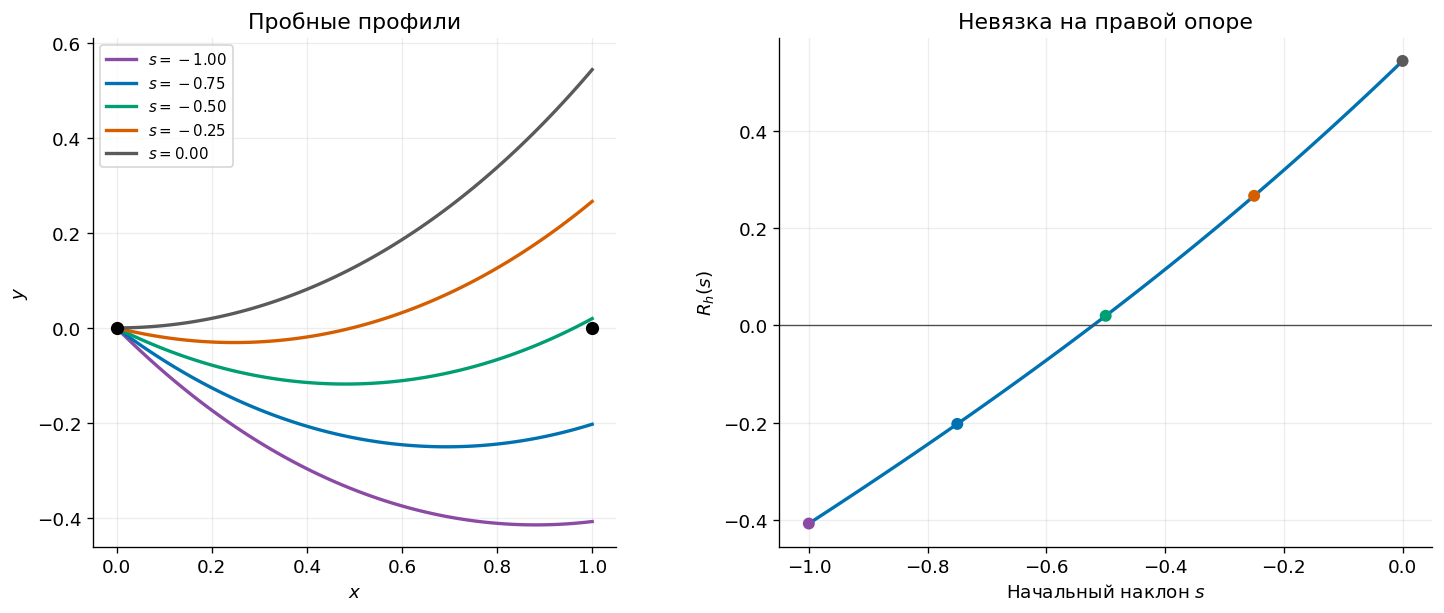

| Левый наклон | Невязка при N = 80 |
| --- | --- |
| -1 | -0.407169 |
| 0 | +0.543081 |

In [3]:
def residual_equal(s, n_steps):
    return integrate(s, 1.0, n_steps)[1][-1, 0]

def shoot_equal(n_steps):
    return bisect_root(lambda s: residual_equal(s, n_steps), -1.0, 0.0)

def exact_equal(x):
    return np.cosh(x - 0.5) - np.cosh(0.5)

s_equal_exact = -np.sinh(0.5)
trials = [-1.0, -0.75, -0.5, -0.25, 0.0]
trial_colors = [PURPLE, BLUE, GREEN, ORANGE, "#5A5A5A"]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), layout="constrained")
for s, color in zip(trials, trial_colors):
    x, u = integrate(s, 1, 80)
    axes[0].plot(x, u[:, 0], color=color, lw=2, label=fr"$s={s:.2f}$")
supports(axes[0], 0)
axes[0].set(title="Пробные профили", ylim=(-0.46, 0.61))
axes[0].legend(loc="upper left", fontsize=9)
s_range = np.linspace(-1, 0, 101)
axes[1].plot(s_range, [residual_equal(s, 80) for s in s_range], color=BLUE, lw=2)
axes[1].axhline(0, color="0.3", lw=0.8)
axes[1].scatter(trials, [residual_equal(s, 80) for s in trials],
                color=trial_colors, s=38, zorder=4)
axes[1].set(xlabel="Начальный наклон $s$", ylabel="$R_h(s)$",
            title="Невязка на правой опоре")
plt.show()
table(["Левый наклон", "Невязка при N = 80"],
      [(f"{s:g}", f"{residual_equal(s,80):+.6f}") for s in [-1, 0]])

При $s=-1$ правый конец оказывается ниже опоры, при $s=0$ — выше неё. Подберём наклон на сетке $N=20$. Помимо невязки правого конца вычислим максимальную ошибку по всем узлам:
$$E_N=\max_{0\le j\le N}\lvert y_{h,j}-y_*(j/N)\rvert.$$
Это ошибка в узлах, а не оценка точности линейных отрезков, которыми соединены точки на рисунке.

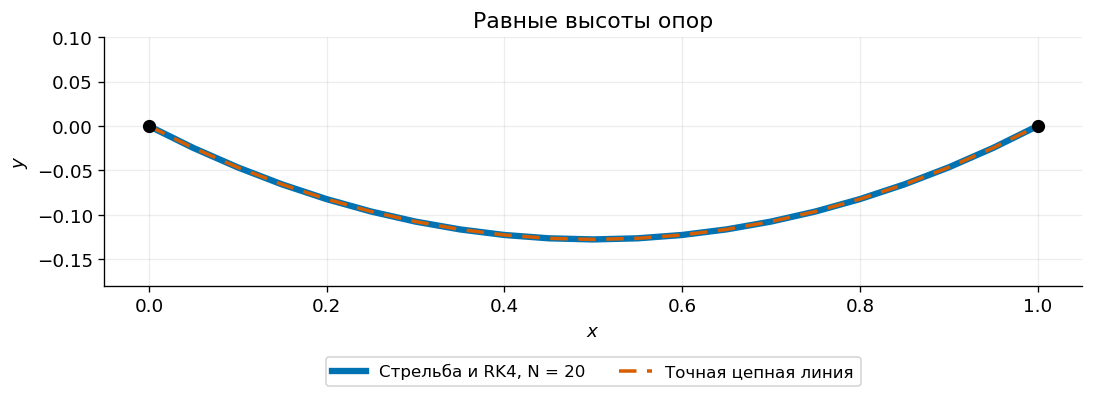

| Величина | Значение |
| --- | --- |
| $s_{20}$ | -0.521095299708 |
| $s_*$ | -0.521095305494 |
| $\lvert s_{20}-s_*\rvert$ | 5.786e-09 |
| $\lvert R_h(s_{20})\rvert$ | 3.639e-15 |
| $E_{20}$ | 1.255e-09 |

In [4]:
s20 = shoot_equal(20)
x20, u20 = integrate(s20, 1, 20)
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
ax.plot(x20, u20[:, 0], color=BLUE, lw=3.8, label="Стрельба и RK4, N = 20", zorder=2)
ax.plot(x20, exact_equal(x20), color=ORANGE, lw=2.1, ls=(0, (5, 3)),
        label="Точная цепная линия", zorder=4)
supports(ax, 0)
ax.set(ylim=(-0.18, 0.10), title="Равные высоты опор")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=2, fontsize=10)
plt.show()
table(["Величина", "Значение"], [
    (r"$s_{20}$", f"{s20:.12f}"),
    (r"$s_*$", f"{s_equal_exact:.12f}"),
    (r"$\lvert s_{20}-s_*\rvert$", f"{abs(s20-s_equal_exact):.3e}"),
    (r"$\lvert R_h(s_{20})\rvert$", f"{abs(u20[-1,0]):.3e}"),
    (r"$E_{20}$", f"{np.max(abs(u20[:,0]-exact_equal(x20))):.3e}"),
])

Подбор даёт невязку порядка $10^{-15}$, но ошибка профиля составляет примерно $1.3\cdot10^{-9}$. Бисекция нашла нуль численной функции $R_h$, которая отличается от невязки непрерывной задачи из-за ошибки интегрирования. Дальнейшее уменьшение допуска бисекции при том же $h$ эту разницу не устраняет.

Повторим весь подбор на каждой из сеток $N=5,10,20,40,80,160,320$. В строке, соответствующей $N$, наблюдаемый порядок обозначим
$$p_N=\log_2\frac{E_{N/2}}{E_N}.$$
Если преобладает ошибка $Ch^4$, деление шага пополам уменьшает её приблизительно в 16 раз. Слева покажем распределение ошибок по нити, справа — зависимость их максимума от шага.

| N | h | $\lvert s_h-s_*\rvert$ | $\lvert R_h\rvert$ | $E_N$ | $p_N$ |
| --- | --- | --- | --- | --- | --- |
| 5 | 0.200000 | 1.030e-06 | 9.145e-15 | 2.922e-07 | — |
| 10 | 0.100000 | 8.321e-08 | 5.315e-15 | 1.966e-08 | 3.894 |
| 20 | 0.050000 | 5.786e-09 | 3.639e-15 | 1.255e-09 | 3.970 |
| 40 | 0.025000 | 3.798e-10 | 6.165e-15 | 7.883e-11 | 3.993 |
| 80 | 0.012500 | 2.432e-11 | 1.459e-14 | 4.940e-12 | 3.996 |
| 160 | 0.006250 | 1.523e-12 | 1.233e-14 | 3.021e-13 | 4.031 |
| 320 | 0.003125 | 1.020e-13 | 5.047e-15 | 2.190e-14 | 3.786 |

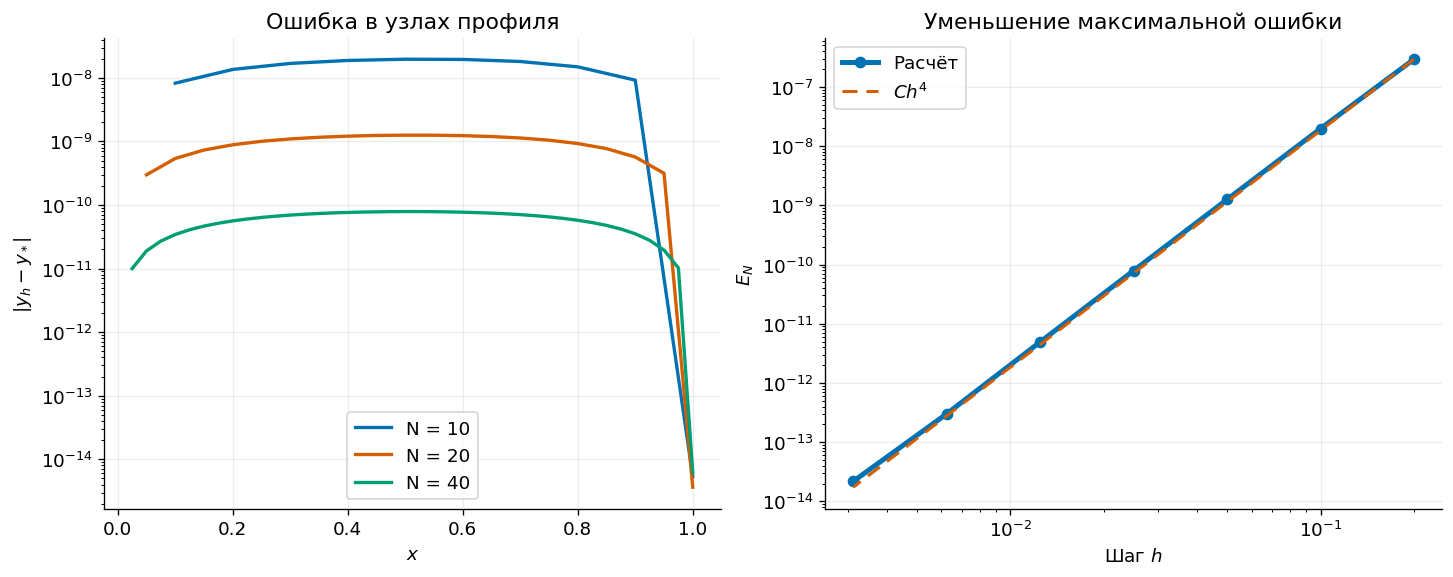

In [5]:
equal_results = []
for n in [5, 10, 20, 40, 80, 160, 320]:
    s = shoot_equal(n)
    x, states = integrate(s, 1, n)
    error = states[:, 0] - exact_equal(x)
    equal_results.append(dict(N=n, s=s, x=x, states=states, error=error,
                              E=np.max(abs(error))))

rows = []
for j, r in enumerate(equal_results):
    order = "—" if j == 0 else f"{np.log2(equal_results[j-1]['E']/r['E']):.3f}"
    rows.append([r['N'], f"{1/r['N']:.6f}", f"{abs(r['s']-s_equal_exact):.3e}",
                 f"{abs(r['states'][-1,0]):.3e}", f"{r['E']:.3e}", order])
table(["N", "h", r"$\lvert s_h-s_*\rvert$", r"$\lvert R_h\rvert$", "$E_N$", "$p_N$"], rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.7), layout="constrained")
for n, color in zip([10, 20, 40], [BLUE, ORANGE, GREEN]):
    r = next(r for r in equal_results if r['N'] == n)
    axes[0].semilogy(r['x'], nonzero(abs(r['error'])), color=color, lw=2, label=f"N = {n}")
axes[0].set(xlabel="$x$", ylabel=r"$|y_h-y_*|$", title="Ошибка в узлах профиля")
axes[0].legend(loc="lower center")
h_values = np.array([1/r['N'] for r in equal_results])
errors = np.array([r['E'] for r in equal_results])
axes[1].loglog(h_values, errors, 'o-', color=BLUE, lw=3, label="Расчёт")
axes[1].loglog(h_values, errors[0]*(h_values/h_values[0])**4,
               color=ORANGE, ls=(0, (5, 3)), lw=1.8, zorder=4, label=r"$Ch^4$")
axes[1].set(xlabel="Шаг $h$", ylabel="$E_N$", title="Уменьшение максимальной ошибки")
axes[1].legend()
plt.show()

На сетках $N=10$–$80$ наблюдаемый порядок приближается к четырём. Для самых мелких шагов ошибка уже сравнима с допуском бисекции и накопленным округлением, поэтому последнее отношение ошибок не обязано давать ровно 16. При этом малая невязка правого конца наблюдается на всех сетках, включая самую грубую.

## 3. Подбор наклона и натяжения по заданной длине

Зададим $y(1)=b=0.2$ и $L=1.2$. Геометрическая совместимость выполнена: длина нити больше расстояния между опорами $\sqrt{1+b^2}\approx1.0198$. Теперь $a$ заранее неизвестно: его нужно подобрать вместе с $s$.

Ищем $z=(s,\alpha)$, где $\alpha=\ln a$. Тогда $a=e^\alpha>0$ при любом конечном допустимом приближении. Два условия образуют систему
$$F_h(z)=\begin{pmatrix}R_y\\R_L\end{pmatrix}
=\begin{pmatrix}y_h(1;s,e^\alpha)-b\\\ell_h(1;s,e^\alpha)-L\end{pmatrix}=0.$$
Обе невязки выражены в одной единице длины. Столбцы якобиана вычисляем центральными разностями:
$$J_{:,j}\approx\frac{F_h(z+d_j e_j)-F_h(z-d_j e_j)}{2d_j},
\qquad d_j=2\cdot10^{-6}\max(1,\lvert z_j\rvert).$$
Поправку получаем решением линейной системы $J\Delta z=-F_h$ и обновляем $z\leftarrow z+\gamma\Delta z$. Сначала пробуем $\gamma=1$; если евклидова норма невязки не уменьшилась, делим $\gamma$ пополам. Остановку проверяем по обеим компонентам: $\max(\lvert R_y\rvert,\lvert R_L\rvert)\le10^{-13}$.

Начнём с $a_0=0.5$. При грубой замене $\sqrt{1+p^2}\approx1$ профиль имеет вид $y\approx sx+x^2/(2a_0)$; условие на правой опоре даёт $s_0=b-1/(2a_0)=-0.8$. Это способ выбрать начальное приближение. В самом интегрировании используется полное нелинейное уравнение.

In [6]:
B, L = 0.2, 1.2
NEWTON_TOL = 1e-13
z0 = np.array([-0.8, np.log(0.5)])

def shoot(z, n_steps):
    with np.errstate(over="raise", invalid="raise", under="raise"):
        a = np.exp(z[1])
    x, states = integrate(z[0], a, n_steps)
    residual = states[-1, [0, 2]] - np.array([B, L])
    return residual, x, states

def jacobian(z, n_steps, fd_step=2e-6):
    jac = np.empty((2, 2))
    for j in range(2):
        d = fd_step*max(1.0, abs(z[j]))
        shift = np.zeros(2)
        shift[j] = d
        jac[:, j] = (shoot(z+shift, n_steps)[0] - shoot(z-shift, n_steps)[0])/(2*d)
    return jac

def newton(z_start, n_steps, tol=NEWTON_TOL, fd_step=2e-6, max_iter=20):
    z = np.asarray(z_start, dtype=float).copy()
    history = []
    for k in range(max_iter + 1):
        residual, x, states = shoot(z, n_steps)
        record = dict(k=k, z=z.copy(), residual=residual.copy(), x=x, states=states)
        history.append(record)
        if np.max(abs(residual)) <= tol:
            return z, history
        if k == max_iter:
            break
        correction = np.linalg.solve(jacobian(z, n_steps, fd_step), -residual)
        if not np.all(np.isfinite(correction)):
            raise RuntimeError("Получена неконечная поправка Ньютона")
        factor = 1.0
        for _ in range(13):
            trial = z + factor*correction
            try:
                trial_residual = shoot(trial, n_steps)[0]
                accepted = np.linalg.norm(trial_residual) < np.linalg.norm(residual)
            except (FloatingPointError, ValueError):
                accepted = False
            if accepted:
                break
            factor *= 0.5
        else:
            raise RuntimeError("Уменьшить невязку не удалось")
        record['factor'] = factor
        z = trial
    raise RuntimeError("Метод Ньютона не достиг допуска")

z40, history40 = newton(z0, 40)
table(["k", "s", "a", "$R_y$", "$R_L$", r"$\gamma$"], [
    [r['k'], f"{r['z'][0]:.9f}", f"{np.exp(r['z'][1]):.9f}",
     f"{r['residual'][0]:+.3e}", f"{r['residual'][1]:+.3e}",
     f"{r['factor']:g}" if 'factor' in r else "—"] for r in history40
])

| k | s | a | $R_y$ | $R_L$ | $\gamma$ |
| --- | --- | --- | --- | --- | --- |
| 0 | -0.800000000 | 0.500000000 | +1.179e-01 | +1.745e-02 | 1 |
| 1 | -0.976119404 | 0.481553223 | +7.944e-03 | +7.655e-03 | 1 |
| 2 | -0.960844984 | 0.489306545 | +2.670e-04 | +1.730e-04 | 1 |
| 3 | -0.960649444 | 0.489471825 | +1.175e-07 | +9.167e-08 | 1 |
| 4 | -0.960649297 | 0.489471918 | +3.650e-14 | +2.576e-14 | — |

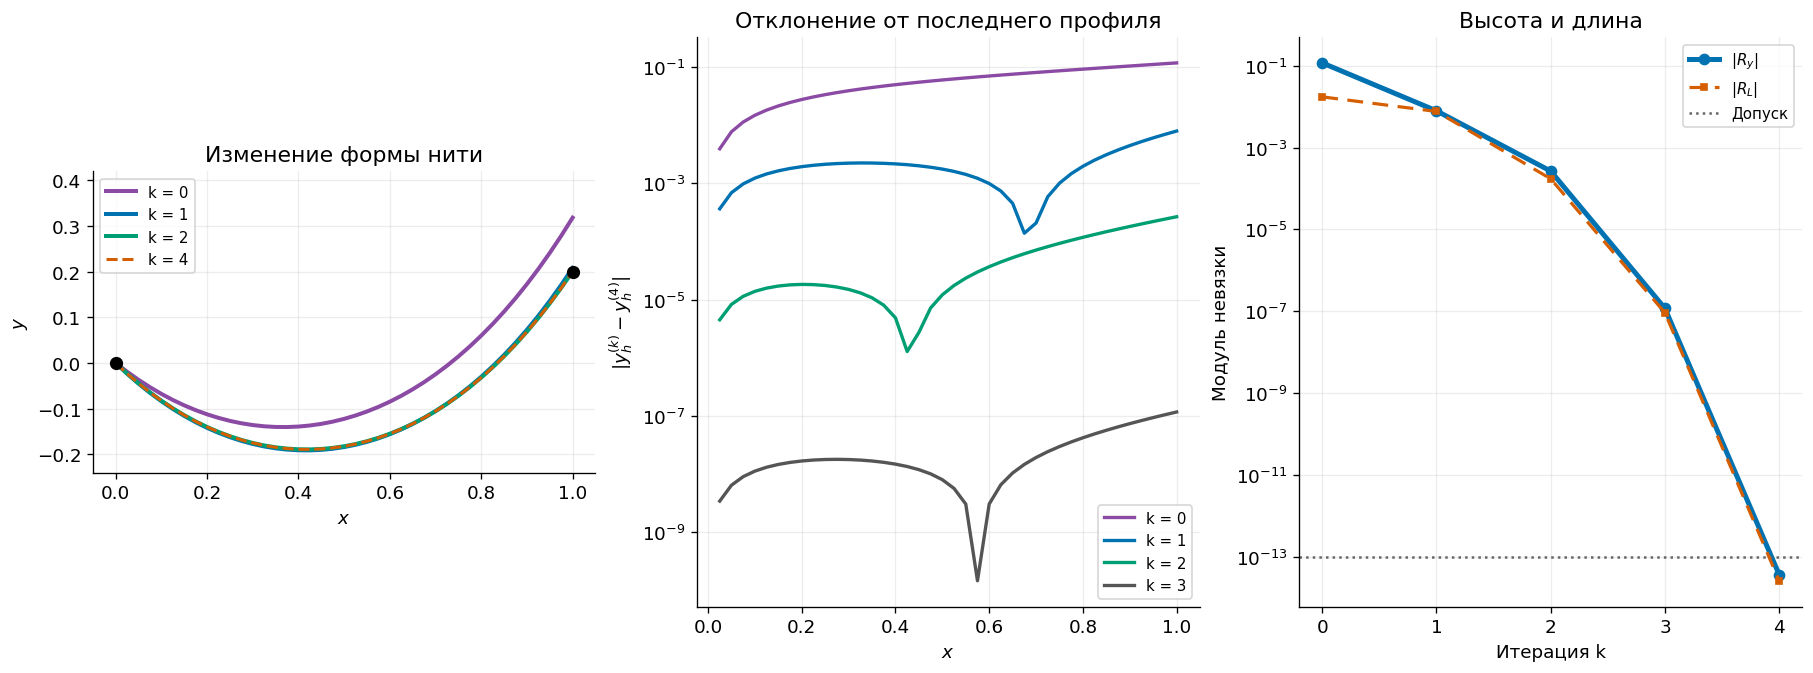

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), layout="constrained")
iteration_colors = [PURPLE, BLUE, GREEN, ORANGE]
last = history40[-1]
for k, color in zip([0, 1, 2, 4], iteration_colors):
    r = history40[k]
    axes[0].plot(r['x'], r['states'][:, 0], color=color,
                 lw=1.8 if k == 4 else 2.4, ls='--' if k == 4 else '-', label=f"k = {k}")
supports(axes[0], B)
axes[0].set(ylim=(-0.24, 0.42), title="Изменение формы нити")
axes[0].legend(loc="upper left", fontsize=9)
for k, color in zip(range(4), [PURPLE, BLUE, GREEN, "#555555"]):
    r = history40[k]
    difference = abs(r['states'][:, 0] - last['states'][:, 0])
    axes[1].semilogy(r['x'], nonzero(difference), color=color, lw=2, label=f"k = {k}")
axes[1].set(xlabel="$x$", ylabel=r"$|y^{(k)}_h-y^{(4)}_h|$",
            title="Отклонение от последнего профиля")
axes[1].legend(loc="lower right", fontsize=9)
residuals = np.array([r['residual'] for r in history40])
k_values = np.arange(len(history40))
axes[2].semilogy(k_values, abs(residuals[:, 0]), 'o-', color=BLUE, lw=3,
                 label=r"$|R_y|$")
axes[2].semilogy(k_values, abs(residuals[:, 1]), color=ORANGE, ls=(0,(5,3)),
                 lw=1.9, marker='s', ms=4, zorder=4, label=r"$|R_L|$")
axes[2].axhline(NEWTON_TOL, color='0.4', ls=':', label="Допуск")
axes[2].set(xlabel="Итерация k", ylabel="Модуль невязки", title="Высота и длина")
axes[2].set_xticks(k_values)
axes[2].legend(loc="upper right", fontsize=9)
plt.show()

Из выбранного начального приближения метод сходится за четыре поправки; во всех случаях принимается полный шаг. Уже после первых итераций профили почти совпадают на масштабе всей нити. Средняя панель показывает, что между ними остаётся различие: сначала порядка сотых, затем порядка $10^{-4}$ и $10^{-7}$. Нулевая разность в левой опоре не показана на логарифмической оси.

Обе невязки последнего приближения меньше $10^{-13}$. Это точность решения системы $F_h=0$ на сетке из 40 шагов. Чтобы оценить точность параметров непрерывной задачи, нужны повторный расчёт с меньшим шагом и независимое сравнение.

## 4. Проверка по цепной линии

При произвольном $a$ интегрирование уравнения для наклона даёт
$$p(x)=\sinh\frac{x-c}{a},\qquad
y(x)=a\left[\cosh\frac{x-c}{a}-\cosh\frac ca\right],$$
$$\ell(x)=a\left[\sinh\frac{x-c}{a}+\sinh\frac ca\right].$$
Здесь $c$ — абсцисса минимума продолженной цепной линии. В нашем решении она находится между опорами. Положим $u=(1/2-c)/a$, $v=1/(2a)$. На правом конце
$$b=2a\sinh u\sinh v,\qquad L=2a\cosh u\sinh v.$$
Деление этих равенств и вычитание их квадратов дают
$$u=\operatorname{artanh}(b/L),\qquad
2a\sinh\frac{1}{2a}=\sqrt{L^2-b^2},$$
$$c=\frac12-a\operatorname{artanh}(b/L),\qquad s=-\sinh(c/a).$$
Таким образом, эталонные параметры можно получить из одного скалярного уравнения без интегрирования ОДУ. Используем бисекцию на $[0.1,2]$ с допусками $5\cdot10^{-16}$ по аргументу и значению функции. Профиль задаётся точной формулой; параметр этой формулы всё же вычислен численно.

В следующей таблице $R_y$ и $R_L$ проверяются на сетке из 2048 шагов при неизменных параметрах каждого подбора. Последний столбец — порядок убывания нормы этой проверочной невязки при удвоении $N$, вычисленный как $p=\log_2(\lVert F_{\rm check}^{(N/2)}\rVert_\infty/\lVert F_{\rm check}^{(N)}\rVert_\infty)$.

Для дополнительной проверки фиксированных $s,a$ удобно записать то же решение через $w=\operatorname{arsinh}s$:
$$y(x)=2a\sinh\frac{x}{2a}\sinh\left(w+\frac{x}{2a}\right),\qquad
\ell(x)=2a\sinh\frac{x}{2a}\cosh\left(w+\frac{x}{2a}\right).$$
Такая запись точно обнуляет $y$ и $\ell$ при $x=0$ и избегает вычитания близких гиперболических функций возле левой опоры.

In [8]:
def closed_profile(x, s, a):
    x = np.asarray(x)
    half = x/(2*a)
    w = np.arcsinh(s)
    y = 2*a*np.sinh(half)*np.sinh(w+half)
    p = np.sinh(w+2*half)
    ell = 2*a*np.sinh(half)*np.cosh(w+half)
    return np.stack([y, p, ell], axis=-1)

equation_a = lambda a: 2*a*np.sinh(0.5/a) - np.sqrt(L**2-B**2)
a_ref = bisect_root(equation_a, 0.1, 2.0, ftol=5e-16, xtol=5e-16)
c_ref = 0.5 - a_ref*np.arctanh(B/L)
s_ref = -np.sinh(c_ref/a_ref)
table(["Эталон", "Значение"], [
    ("s", f"{s_ref:.12f}"), ("a", f"{a_ref:.12f}"), ("c", f"{c_ref:.12f}")
])

refinement = []
for n in [20, 40, 80, 160, 320]:
    z, history = newton(z0, n)
    own, x, states = shoot(z, n)
    # Параметры не меняем при проверочном интегрировании.
    check = shoot(z, 2048)[0]
    refinement.append(dict(N=n, z=z, own=own, check=check, x=x, states=states,
                           Es=abs(z[0]-s_ref), Ea=abs(np.exp(z[1])-a_ref)))

rows = []
for j, r in enumerate(refinement):
    order = "—" if j == 0 else f"{np.log2(np.max(abs(refinement[j-1]['check']))/np.max(abs(r['check']))):.2f}"
    rows.append([r['N'], f"{np.max(abs(r['own'])):.2e}",
                 f"{r['check'][0]:+.2e}", f"{r['check'][1]:+.2e}",
                 f"{r['Es']:.2e}", f"{r['Ea']:.2e}", order])
table(["N", r"$\lVert F_h\rVert_\infty$", r"$R_y$ (2048)", r"$R_L$ (2048)",
       r"$\lvert s_h-s_*\rvert$", r"$\lvert a_h-a_*\rvert$", "p"], rows)

| Эталон | Значение |
| --- | --- |
| s | -0.960649286891 |
| a | 0.489471925395 |
| c | 0.417653143250 |

| N | $\lVert F_h\rVert_\infty$ | $R_y$ (2048) | $R_L$ (2048) | $\lvert s_h-s_*\rvert$ | $\lvert a_h-a_*\rvert$ | p |
| --- | --- | --- | --- | --- | --- | --- |
| 20 | 3.65e-14 | +1.58e-07 | +1.19e-07 | 1.82e-07 | 1.20e-07 | — |
| 40 | 3.65e-14 | +1.08e-08 | +7.46e-09 | 9.75e-09 | 7.29e-09 | 3.87 |
| 80 | 3.65e-14 | +7.02e-10 | +4.64e-10 | 5.51e-10 | 4.47e-10 | 3.94 |
| 160 | 3.62e-14 | +4.48e-11 | +2.89e-11 | 3.26e-11 | 2.77e-11 | 3.97 |
| 320 | 3.62e-14 | +2.86e-12 | +1.83e-12 | 2.00e-12 | 1.74e-12 | 3.97 |

При $N=40$ собственная невязка порядка $10^{-14}$ соседствует с проверочной невязкой порядка $10^{-8}$. Подобранные параметры компенсируют ошибку грубого интегрирования, поэтому попадание в правую опору на этой сетке ещё не означает такое же попадание для точного профиля.

В таблице при каждом удвоении $N$ начальное приближение остаётся прежним и Ньютон выполняется заново. Ошибки параметров и проверочная невязка убывают с порядком около четырёх. Итоговыми примем параметры сетки $N=320$: их отличия от эталона имеют порядок $10^{-12}$.

Теперь сохраним эти параметры неизменными и сравним два более точных интегрирования, на 1024 и 2048 шагах, с формулой для тех же $s,a$. Это позволяет проверить, что остаточные ошибки правой высоты и длины относятся к найденным параметрам, а не к недостаточно мелкой проверочной сетке. Также повторим подбор с другим шагом численного дифференцирования якобиана.

In [9]:
final = refinement[-1]
z_final = final['z']
s_final, a_final = z_final[0], np.exp(z_final[1])
endpoint_closed = closed_profile(1.0, s_final, a_final)[[0, 2]] - [B, L]
verification = []
for n in [1024, 2048]:
    residual, x, states = shoot(z_final, n)
    same_parameters = closed_profile(x, s_final, a_final)
    reference = closed_profile(x, s_ref, a_ref)
    verification.append(dict(N=n, x=x, states=states, residual=residual,
                              integration_error=np.max(abs(states[:,0]-same_parameters[:,0])),
                              total_error=np.max(abs(states[:,0]-reference[:,0]))))
table(["Проверка при фиксированных s, a", "$R_y$", "$R_L$"],
      [[f"RK4, N = {r['N']}", f"{r['residual'][0]:+.3e}", f"{r['residual'][1]:+.3e}"]
       for r in verification] + [["Формула цепной линии", f"{endpoint_closed[0]:+.3e}", f"{endpoint_closed[1]:+.3e}"]])
table(["Проверочная сетка", "Ошибка интегрирования y при тех же s, a", "Ошибка y относительно краевого решения"],
      [[r['N'], f"{r['integration_error']:.2e}", f"{r['total_error']:.2e}"] for r in verification])

fd_rows = []
for d in [2e-5, 2e-6, 2e-7]:
    z_d, hist_d = newton(z0, 320, fd_step=d)
    difference = max(abs(z_d[0]-s_final), abs(np.exp(z_d[1])-a_final))
    fd_rows.append([f"{d:.0e}", len(hist_d)-1, f"{difference:.2e}"])
table(["Множитель шага разности", "Поправок Ньютона", "Максимальное изменение s и a"], fd_rows)

| Проверка при фиксированных s, a | $R_y$ | $R_L$ |
| --- | --- | --- |
| RK4, N = 1024 | +2.832e-12 | +1.811e-12 |
| RK4, N = 2048 | +2.857e-12 | +1.829e-12 |
| Формула цепной линии | +2.859e-12 | +1.829e-12 |

| Проверочная сетка | Ошибка интегрирования y при тех же s, a | Ошибка y относительно краевого решения |
| --- | --- | --- |
| 1024 | 2.69e-14 | 2.83e-12 |
| 2048 | 2.30e-15 | 2.86e-12 |

| Множитель шага разности | Поправок Ньютона | Максимальное изменение s и a |
| --- | --- | --- |
| 2e-05 | 4 | 4.66e-15 |
| 2e-06 | 4 | 0.00e+00 |
| 2e-07 | 4 | 5.44e-15 |

Обе проверочные сетки дают практически одинаковые ошибки правого конца: около $2.9\cdot10^{-12}$ по высоте и $1.8\cdot10^{-12}$ по длине. Формула цепной линии с теми же параметрами подтверждает эти значения. Собственная погрешность проверочного интегрирования существенно меньше. Изменение шага разностного якобиана в десять раз в обе стороны также не меняет сообщаемые ниже десять десятичных знаков $s$ и $a$.

## 5. Форма нити и натяжение

В найденной цепной линии нижняя точка имеет координаты
$$x_{\min}=c=-a\operatorname{arsinh}s,\qquad y_{\min}=a[1-\cosh(c/a)].$$
Для опор разной высоты полезно отдельно определить провисание относительно соединяющего их отрезка:
$$D(x)=bx-y(x).$$
В точке максимального провисания $D'=b-p=0$, поэтому
$$x_D=c+a\operatorname{arsinh}b.$$
Эта точка лежит правее нижней точки: минимум высоты соответствует $p=0$, максимум зазора относительно наклонного отрезка — $p=b=0.2$.

Полное натяжение выражается через наклон:
$$\frac{\mathcal T(x)}q=a\sqrt{1+p(x)^2}.$$
В нижней точке $\mathcal T=H=qa$, в опорах натяжение больше. Геометрические характеристики ниже вычислены по формуле цепной линии с найденными численно $s,a$; профиль и натяжение на графике также сопоставлены с эталоном краевой задачи.

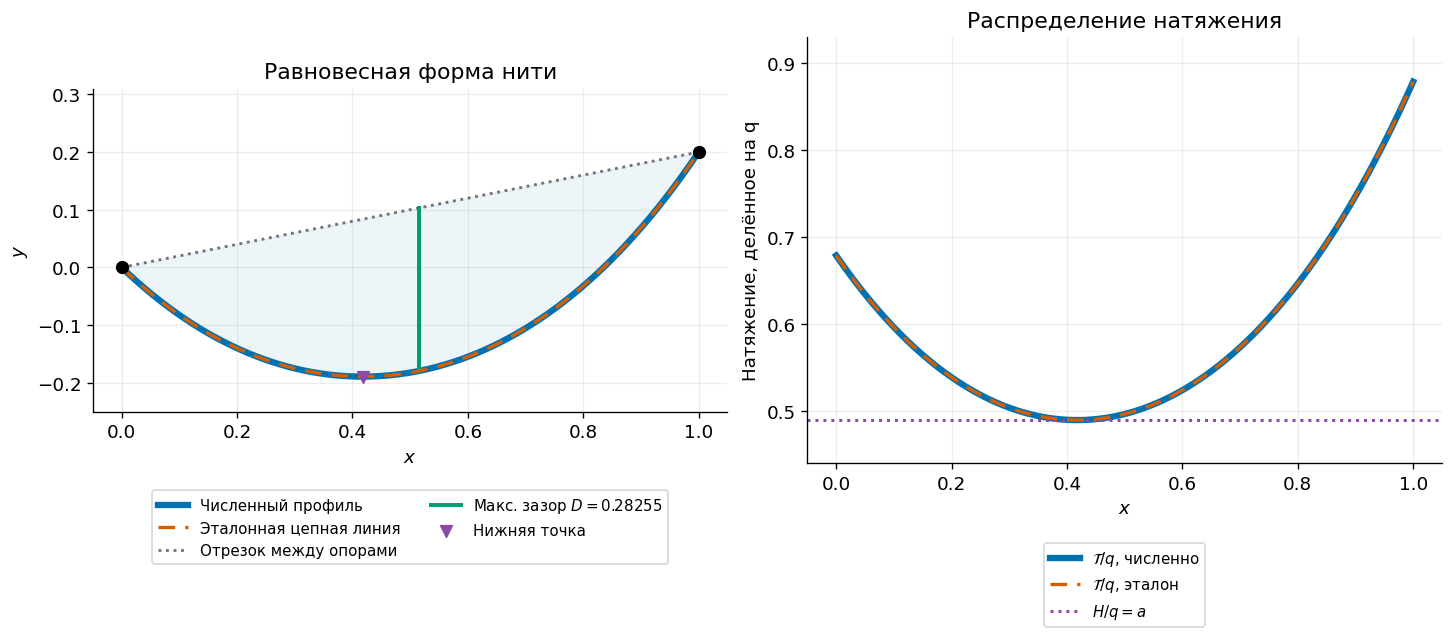

| Величина | Значение |
| --- | --- |
| Начальный наклон s | -0.9606492869 |
| a = H/q | 0.4894719254 |
| Абсцисса нижней точки | 0.41765314 |
| Минимальная высота | -0.18926294 |
| Абсцисса максимального провисания | 0.51490637 |
| Максимальное провисание относительно отрезка | 0.28255076 |
| $\mathcal T(0)/q$ | 0.67873486 |
| $\mathcal T(1)/q$ | 0.87873486 |

: 

In [ ]:
c_final = -a_final*np.arcsinh(s_final)
x_sag = c_final + a_final*np.arcsinh(B)
y_min = closed_profile(c_final, s_final, a_final)[0]
y_sag = closed_profile(x_sag, s_final, a_final)[0]
sag = B*x_sag-y_sag
check = verification[-1]
x, states = check['x'], check['states']
reference = closed_profile(x, s_ref, a_ref)
tension = a_final*np.hypot(1, states[:,1])
tension_ref = a_ref*np.hypot(1, reference[:,1])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), layout="constrained")
axes[0].fill_between(x, states[:,0], B*x, color=BLUE, alpha=0.07)
axes[0].plot(x, states[:,0], color=BLUE, lw=3.8, zorder=2, label="Численный профиль")
axes[0].plot(x, reference[:,0], color=ORANGE, lw=2, ls=(0,(5,3)), zorder=4,
             label="Эталонная цепная линия")
axes[0].plot(x, B*x, color='0.45', ls=':', lw=1.7, label="Отрезок между опорами")
axes[0].plot([x_sag,x_sag], [y_sag,B*x_sag], color=GREEN, lw=2.4,
             label=fr"Макс. зазор $D={sag:.5f}$")
axes[0].scatter([c_final], [y_min], marker='v', color=PURPLE, s=48, zorder=6,
                label="Нижняя точка")
supports(axes[0], B)
axes[0].set(ylim=(-0.25, 0.31), title="Равновесная форма нити")
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5,-0.22), fontsize=9, ncol=2)

axes[1].plot(x, tension, color=BLUE, lw=3.8, label=r"$\mathcal{T}/q$, численно")
axes[1].plot(x, tension_ref, color=ORANGE, lw=2, ls=(0,(5,3)), zorder=4,
             label=r"$\mathcal{T}/q$, эталон")
axes[1].axhline(a_final, color=PURPLE, ls=':', lw=1.8, label=r"$H/q=a$")
axes[1].set(xlabel="$x$", ylabel="Натяжение, делённое на q", title="Распределение натяжения",
            ylim=(0.44,0.93))
axes[1].legend(loc='upper center', bbox_to_anchor=(0.5,-0.17), fontsize=9)
plt.show()

table(["Величина", "Значение"], [
    ("Начальный наклон s", f"{s_final:.10f}"),
    ("a = H/q", f"{a_final:.10f}"),
    ("Абсцисса нижней точки", f"{c_final:.8f}"),
    ("Минимальная высота", f"{y_min:.8f}"),
    ("Абсцисса максимального провисания", f"{x_sag:.8f}"),
    ("Максимальное провисание относительно отрезка", f"{sag:.8f}"),
    (r"$\mathcal T(0)/q$", f"{tension[0]:.8f}"),
    (r"$\mathcal T(1)/q$", f"{tension[-1]:.8f}"),
])

Нить имеет длину $1.2$, на $0.18020$ больше прямого расстояния между опорами. Её нижняя точка находится при $x\approx0.41765$ и $y\approx-0.18926$. Максимальный зазор относительно отрезка между опорами равен $0.28255$ и достигается при $x\approx0.51491$. Правая опора выше, и полное натяжение возле неё больше: $\mathcal T(1)/q\approx0.87873$ против $\mathcal T(0)/q\approx0.67873$.

Связь длины с горизонтальным натяжением определяется уравнением
$$g(a)=2a\sinh\frac1{2a}=\sqrt{L^2-b^2}.$$
При $v=1/(2a)>0$ имеем $g'(a)=2(\sinh v-v\cosh v)<0$: функция $v\cosh v-\sinh v$ равна нулю при $v=0$ и имеет положительную производную $v\sinh v$. Значит, при фиксированных опорах увеличение длины требует меньшего $a$ и меньшего $H=qa$; нить провисает глубже. Уменьшение длины приближает её к прямому отрезку и увеличивает горизонтальное натяжение. Этот вывод относится к $H$; полное натяжение зависит также от положения на нити.

Тот же знак производной показывает, что положительное $a$ для заданных $b,L$ единственно: $g(a)$ убывает от бесконечности до 1, а $\sqrt{L^2-b^2}>1$. После нахождения $a$ условия однозначно определяют $c$ и $s$.

Равновесие по вертикали выражается равенством
$$a[p(1)-p(0)]=\ell(1)=L.$$
Оно объясняет, как опоры удерживают вес всей нити. Однако в используемой системе $\ell'=ap'$, поэтому RK4 сохраняет разность $\ell-a(p-s)$ с точностью округления при любом шаге. Это равенство само по себе не проверяет точность формы. Для такой проверки использованы измельчение шага и формула цепной линии.

## 6. Результат

При $a=1$ метод стрельбы воспроизводит симметричный профиль с начальным наклоном $s=-\sinh(1/2)\approx-0.5210953055$. Максимальная ошибка в узлах убывает с четвёртым порядком: от $2.9\cdot10^{-7}$ при $N=5$ до $4.9\cdot10^{-12}$ при $N=80$. Невязка правой опоры остаётся около допуска поиска корня и не характеризует эту ошибку.

Для опор $(0,0)$, $(1,0.2)$ и длины $L=1.2$ получено
$$s\approx-0.9606492869,\qquad a=H/q\approx0.4894719254.$$
Подбор выполнен двумерным методом Ньютона по высоте правого конца и длине. После повторного подбора на сетке $N=320$ более точное интегрирование даёт ошибки около $2.9\cdot10^{-12}$ по высоте и $1.8\cdot10^{-12}$ по длине. Их подтверждает аналитическая форма с теми же параметрами. Максимальное провисание относительно отрезка между опорами составляет $0.28255$.

Материалы: [условие задания 4.2](https://github.com/yartmihant/Students6Year2026/blob/ae205fd7847052bca2483180287d1178564684e3/README.md), [метод стрельбы](https://github.com/yartmihant/Students6Year2026/blob/ae205fd7847052bca2483180287d1178564684e3/lesson4/shooting_method.ipynb), [многомерный метод Ньютона](https://github.com/yartmihant/Students6Year2026/blob/ae205fd7847052bca2483180287d1178564684e3/lesson4/newton_bratu.ipynb).